In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df=pd.read_excel("/content/drive/MyDrive/sosyal_medya_veri.xlsx")

# ülke sütununu kullanmayacağımız için kaldırdık
df = df.drop(columns=['Country'])

df.head(5)

,Student_ID,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,1,22,Male,High School,40,Twitter,No,76,86,Positive
1,1,19,Female,Undergraduate,52,Instagram,Yes,65,60,Negative
2,2,23,Female,Undergraduate,27,YouTube,No,78,77,Positive
3,2,22,Male,Graduate,21,Twitter,No,75,80,Neutral
4,3,23,Female,High School,38,Instagram,No,74,71,Positive


In [5]:
#eksik değer kontrolü
display(df.isnull().sum())

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0
Overall_Impact,0


In [6]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,51.036364,65.987097,62.151320
std,267.058174,1.758557,16.773410,12.070453,12.826784
min,1.000000,18.000000,15.000000,38.000000,40.000000
25%,214.000000,19.000000,38.000000,56.000000,50.000000
50%,427.000000,21.000000,51.000000,66.000000,60.000000
75%,640.000000,22.000000,63.000000,75.000000,70.000000
max,1000.000000,24.000000,85.000000,96.000000,90.000000


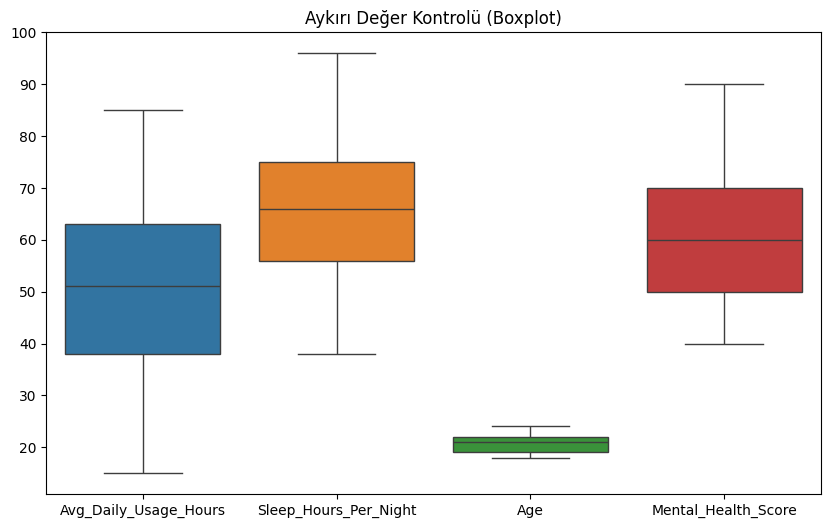

In [7]:
# aykırı ve gürültülü değer analizi
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Age', 'Mental_Health_Score']])
plt.title('Aykırı Değer Kontrolü (Boxplot)')
plt.savefig('aykiri_degerler.png')

In [ ]:
# kutu grafiğine göre aykırı veya gürültülü değer bulunmamaktadır.

In [8]:
#Bu aşamada kategorik yani metin olan değişken ve sütunları sayıya çeviriyoruz
le=LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])
df["Most_Used_Platform"]=le.fit_transform(df["Most_Used_Platform"])
df["Academic_Level"]=le.fit_transform(df["Academic_Level"])

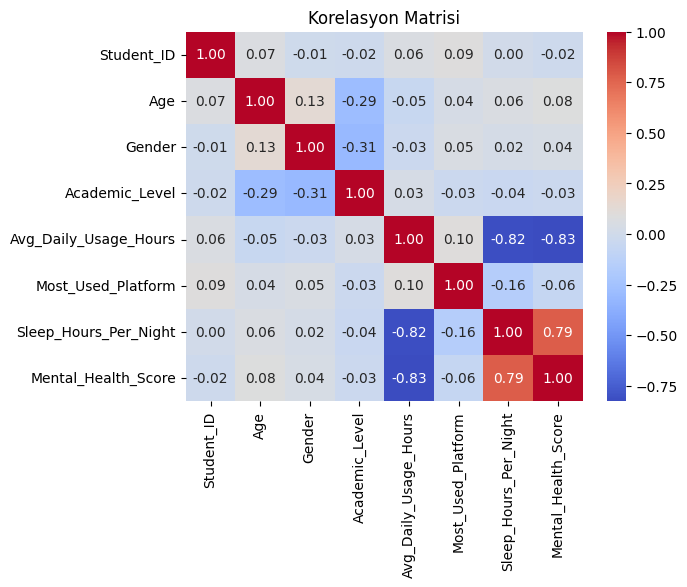

In [9]:


# korelasyon matrisi oluşturma
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasyon Matrisi')
plt.show()

In [10]:
#Hedef değişkenimiz olan sütunu (y) ve özellikleri belirleyelim (x)
y=df['Affects_Academic_Performance']
x=df[['Academic_Level','Age','Gender','Avg_Daily_Usage_Hours','Most_Used_Platform','Sleep_Hours_Per_Night','Mental_Health_Score']]

In [11]:
#Veriyi eğitim (%80) ve test (%20) olarak ayıralım
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
clf.fit(x_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [13]:
#Eğitim verileriyle tahmin:
y_pred_train=clf.predict(x_train)
y_pred=clf.predict(x_test)

#Tahmin edilen değerler

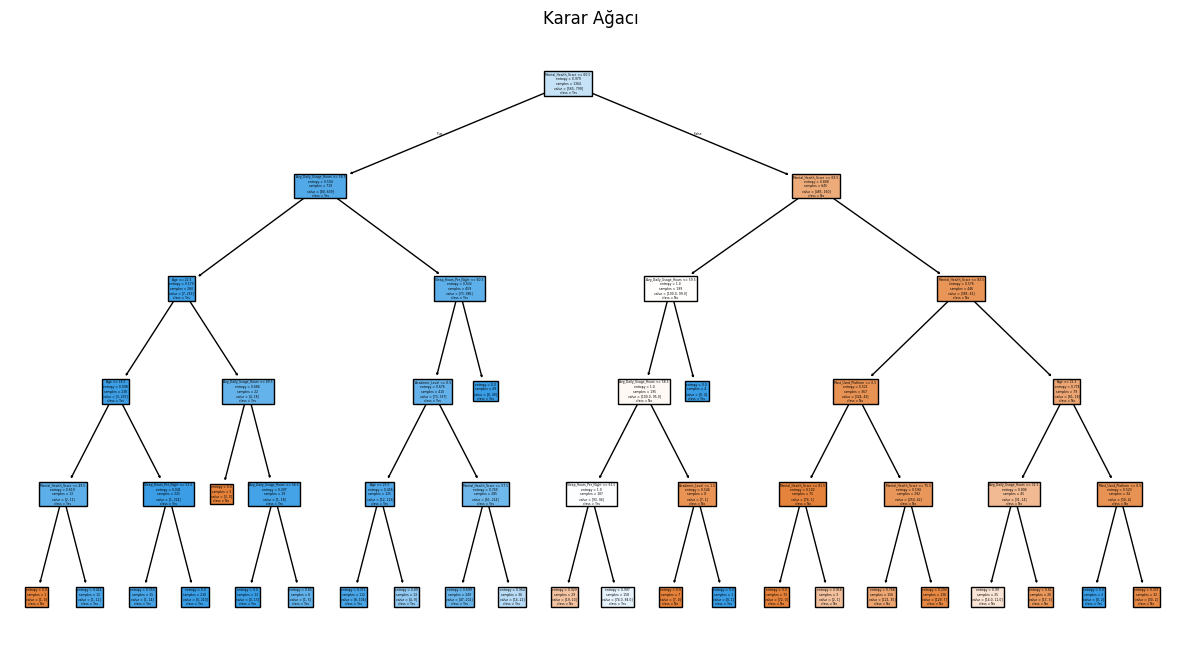

In [20]:
#Yaptığımız sınıflandırmayı şöyle görselleştirebiliriz:
plt.figure(figsize=(15, 8))
plot_tree(clf, feature_names=x.columns, class_names=y.unique(), filled=True)
plt.title("Karar Ağacı")
plt.show()

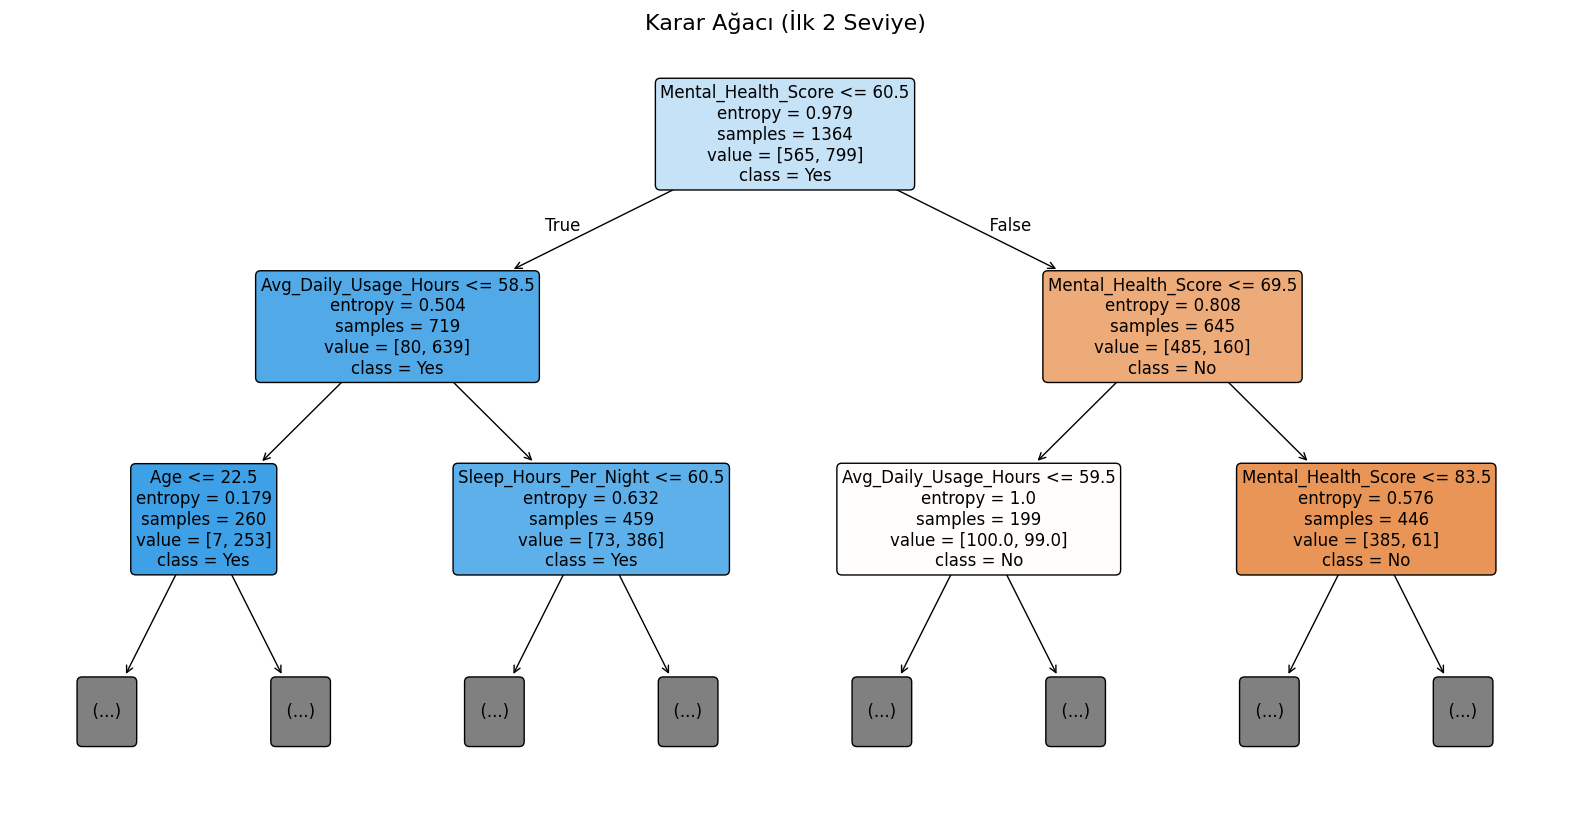

In [21]:
plt.figure(figsize=(20, 10))  # Genişliği biraz daha artırdık

# max_depth=2 ekleyerek sadece ilk 2 kırılımı (en önemli özellikleri) gösteriyoruz
plot_tree(clf,
          feature_names=x.columns,
          class_names=y.unique(),
          filled=True,
          rounded=True,
          max_depth=2,  # Kilit nokta burası!
          fontsize=12)  # Yazı boyutunu okunabilir yaptık

plt.title("Karar Ağacı (İlk 2 Seviye)", fontsize=16)
plt.show()

In [14]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Model Doğruluk Oranı: {accuracy:.2f}")
print(conf_matrix)
print(class_report)

Model Doğruluk Oranı: 0.82
[[101  28]
 [ 34 178]]
              precision    recall  f1-score   support

          No       0.75      0.78      0.77       129
         Yes       0.86      0.84      0.85       212

    accuracy                           0.82       341
   macro avg       0.81      0.81      0.81       341
weighted avg       0.82      0.82      0.82       341



In [15]:
results_df = pd.DataFrame({"Gerçek Değer": y_test, "Tahmin Edilen": y_pred})
results_df

,Gerçek Değer,Tahmin Edilen
1046,Yes,Yes
745,Yes,No
785,Yes,No
367,Yes,Yes
1029,Yes,Yes
...,...,...
128,Yes,No
1073,Yes,Yes
366,Yes,No
342,No,Yes


In [16]:

fp = ((results_df['Gerçek Değer'] == 'No') & (results_df['Tahmin Edilen'] == 'Yes')).sum()
fn = ((results_df['Gerçek Değer'] == 'Yes') & (results_df['Tahmin Edilen'] == 'No')).sum()

print("False Positive (I. Tip Hata - No yerine Yes denilen):", fp)
print("False Negative (II. Tip Hata - Yes yerine No denilen):", fn)

False Positive (I. Tip Hata - No yerine Yes denilen): 28
False Negative (II. Tip Hata - Yes yerine No denilen): 34


In [17]:
print(f"Model Doğruluk Oranı: {accuracy:.2f}")

Model Doğruluk Oranı: 0.82
